# LSTM

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ta
import torch
import torch.nn as nn

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from torch.utils.data import DataLoader, TensorDataset

In [40]:
apple_df = pd.read_csv('datas/apple_data.csv')

In [41]:
apple_df.head()

,date,open,high,low,close,volume
0,2010-01-04,7.62,7.66,7.58,7.64,493729600
1,2010-01-05,7.66,7.70,7.62,7.66,601904800
2,2010-01-06,7.66,7.69,7.53,7.53,552160000
3,2010-01-07,7.56,7.57,7.47,7.52,477131200
4,2010-01-08,7.51,7.57,7.47,7.57,447876740


In [42]:
apple_df.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume'], dtype='object')

In [43]:
apple_df.shape

(3848, 6)

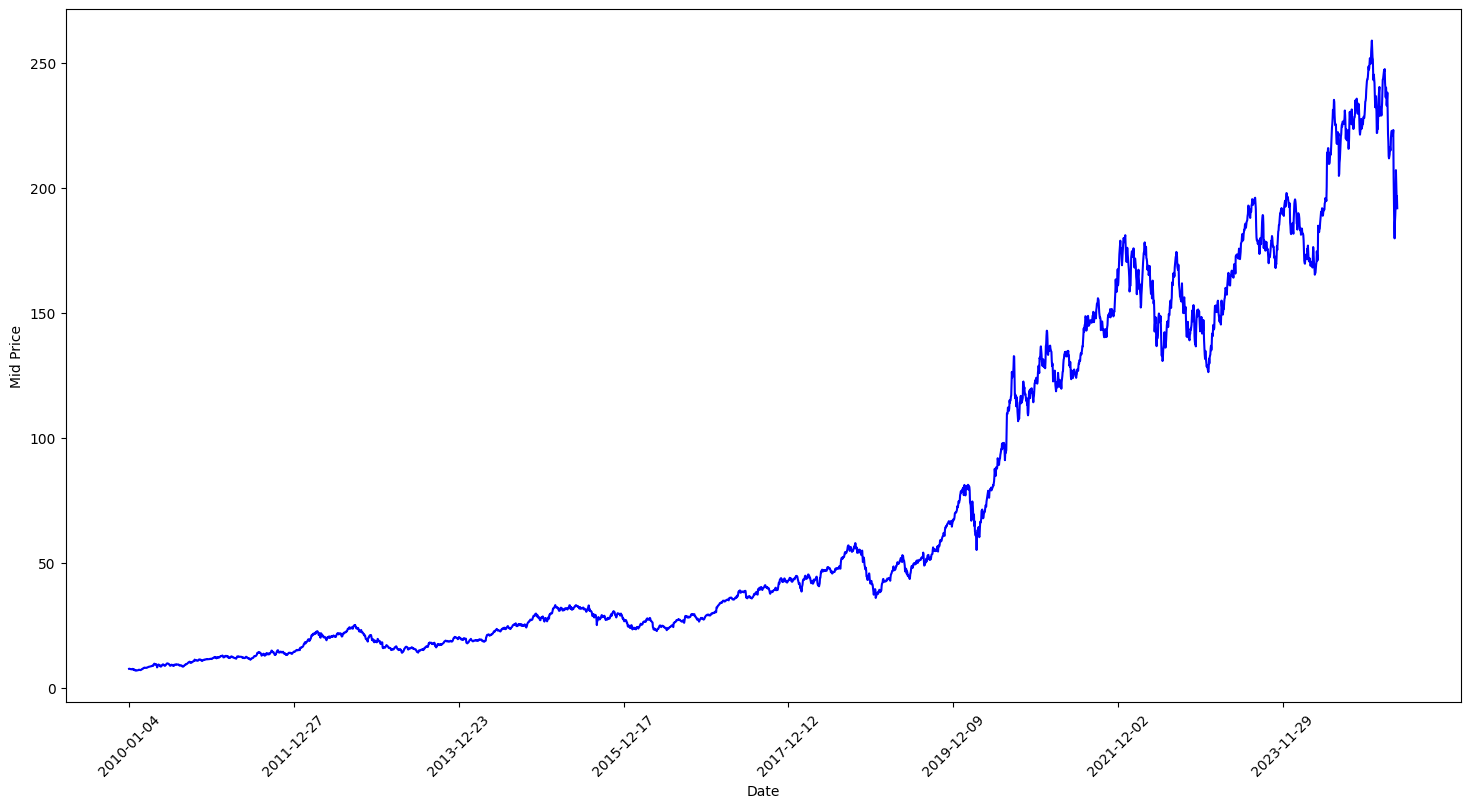

In [44]:
plt.figure(figsize=(18,9))
plt.plot(range(apple_df.shape[0]), (apple_df['low']+apple_df['high'])/2, color='blue', label='Average Price')
plt.xticks(range(0, apple_df.shape[0], 500), apple_df['date'].loc[::500], rotation=45)
plt.xlabel('Date')
plt.ylabel('Mid Price')
plt.show()

## Sans features engineering

### 1 - Création de séquences

In [45]:
def create_sequences(data, seq_length, target_col_index=None):
    X = []
    y = []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        if target_col_index is not None:
            y.append(data[i + seq_length][target_col_index])  # Ex : close = 3
        else:
            y.append(data[i + seq_length])  # Toute la ligne
    return np.array(X), np.array(y)

### 2 - Normalisation

In [46]:
features = ['open', 'high', 'low', 'close', 'volume']
data = apple_df[features].values

scaler_X = MinMaxScaler()
scaled_features = scaler_X.fit_transform(data)

scaler_y = MinMaxScaler()
scaled_close = scaler_y.fit_transform(apple_df[['close']])

seq_length = 60
total_data = len(apple_df)

train_len = int(total_data * 0.8)

X_test_data = scaled_features[train_len-seq_length:]
y_test_data = scaled_close[train_len-seq_length:]


X_train, y_train = create_sequences(scaled_features[:train_len], seq_length=seq_length)
X_test, y_test = create_sequences(X_test_data, seq_length=seq_length)

### 3 - Conversion en tenseurs PyTorch + Dataloader

In [47]:
# Convertir en tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

# Création des datasets et loaders
batch_size = 64
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

### 4 - Modèle LSTM

In [48]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=5, hidden_size=60, num_layers=2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)  # out: (batch_size, seq_len, hidden_size)
        out = out[:, -1, :]    # on ne garde que le dernier pas de temps
        out = self.linear(out) # projection vers une sortie de dimension 1
        return out

In [49]:
model = LSTMModel()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### 5 - Entraînement

In [50]:
n_epochs = 20

for epoch in range(n_epochs):
    model.train()
    for X_batch, y_batch in train_loader:
        output = model(X_batch)
        loss = criterion(output, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            y_val_pred = model(X_test)
            val_loss = criterion(y_val_pred, y_test)
        
    print(f'Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.8f}, Validation Loss: {val_loss.item():.8f}')

/var/www/html/cours/brief15_prediction_bourse/venv/lib/python3.12/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([64, 5])) that is different to the input size (torch.Size([64, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/var/www/html/cours/brief15_prediction_bourse/venv/lib/python3.12/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([770, 5])) that is different to the input size (torch.Size([770, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/var/www/html/cours/brief15_prediction_bourse/venv/lib/python3.12/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([10, 5])) that is different to the input size (torch.Size([10, 1]))

Epoch 1/20, Loss: 0.01440307, Validation Loss: 0.08231401
Epoch 2/20, Loss: 0.00784415, Validation Loss: 0.07755017
Epoch 3/20, Loss: 0.00895650, Validation Loss: 0.07729366
Epoch 4/20, Loss: 0.02723409, Validation Loss: 0.07688432
Epoch 5/20, Loss: 0.01246007, Validation Loss: 0.07699744
Epoch 6/20, Loss: 0.01028703, Validation Loss: 0.07715126
Epoch 7/20, Loss: 0.00794390, Validation Loss: 0.07700417
Epoch 8/20, Loss: 0.01605075, Validation Loss: 0.07695174
Epoch 9/20, Loss: 0.01156629, Validation Loss: 0.07700216
Epoch 10/20, Loss: 0.00274938, Validation Loss: 0.07724608
Epoch 11/20, Loss: 0.01900789, Validation Loss: 0.07716422
Epoch 12/20, Loss: 0.01126229, Validation Loss: 0.07742560
Epoch 13/20, Loss: 0.00650152, Validation Loss: 0.07727624
Epoch 14/20, Loss: 0.01079025, Validation Loss: 0.07722469
Epoch 15/20, Loss: 0.00221013, Validation Loss: 0.07702824
Epoch 16/20, Loss: 0.00542551, Validation Loss: 0.07737610
Epoch 17/20, Loss: 0.01484054, Validation Loss: 0.07699679
Epoch 

### 6 - Evaluation

In [51]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test).numpy()

y_test_close = y_test[:, 3:4]
print("y_pred shape:", y_pred.shape)
print("y_test shape:", y_test.shape)
print("y_test_close shape:", y_test_close.shape)

# Inverse scaling uniquement pour close
y_pred_rescaled = scaler_y.inverse_transform(y_pred)
y_test_rescaled = scaler_y.inverse_transform(y_test_close.numpy())

# Calcul des métriques
mse = mean_squared_error(y_test_rescaled, y_pred_rescaled)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
mape = np.mean(np.abs((y_test_rescaled - y_pred_rescaled) / y_test_rescaled)) * 100

print(f"MSE : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"MAPE : {mape:.4f}%")

y_pred shape: (770, 1)
y_test shape: torch.Size([770, 5])
y_test_close shape: torch.Size([770, 1])
MSE : 1466.4834
RMSE : 38.2947
MAE : 36.8715
MAPE : 19.7894%


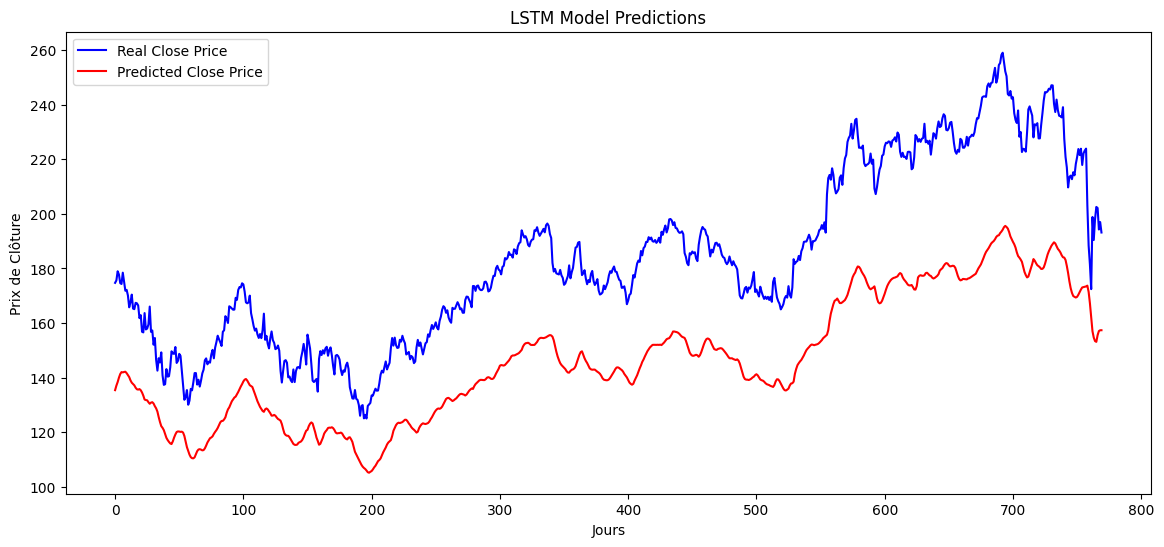

In [52]:
plt.figure(figsize=(14, 6))
plt.plot(y_test_rescaled, label='Real Close Price', color='blue')
plt.plot(y_pred_rescaled, label='Predicted Close Price', color='red')
plt.title('LSTM Model Predictions')
plt.xlabel('Jours')
plt.ylabel('Prix de Clôture')
plt.legend()
plt.show()

## Avec Features engineering

Différentes features :
- moyennes mobiles (5, 10, 20 et 50 jours)
- rsi et MACD
- momentum : vitesse de changement des prix
- bandes de bollinger (volatilité et les niveaux de prix extrêmes)
- deltas (1, 3, 5, 10, 20, 30 jours)

In [53]:
df_features = apple_df.copy()

A - **Moyenne mobile**

In [54]:
# Moyenne mobile sur différentes périodes
df_features['MA_5'] = df_features['close'].rolling(window=5).mean()
df_features['MA_10'] = df_features['close'].rolling(window=10).mean()
df_features['MA_20'] = df_features['close'].rolling(window=20).mean()
df_features['MA_50'] = df_features['close'].rolling(window=50).mean()

# ratios de prix par rapport aux moyenne mobiles
df_features['MA_5_ratio'] = df_features['close'] / df_features['MA_5']
df_features['MA_10_ratio'] = df_features['close'] / df_features['MA_10']
df_features['MA_20_ratio'] = df_features['close'] / df_features['MA_20']
df_features['MA_50_ratio'] = df_features['close'] / df_features['MA_50']

B - **RSI**

In [55]:
def calaculate_rsi(data, period=14):
    delta = data.diff()
    gain = delta.where(delta > 0, 0).rolling(window=period).mean()
    loss = -delta.where(delta < 0, 0).rolling(window=period).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df_features['RSI_14'] = calaculate_rsi(df_features['close'], 14)

C - **MACD**

In [56]:
macd = ta.trend.MACD(close=df_features['close'])
apple_df['macd'] = macd.macd()
apple_df['macd_signal'] = macd.macd_signal()
apple_df['macd_diff'] = macd.macd_diff()

D - **Momentum**

In [57]:
df_features['Momentum_5'] = df_features['close'] / df_features['close'].shift(5) - 1
df_features['Momentum_10'] = df_features['close'] / df_features['close'].shift(10) - 1
df_features['Momentum_20'] = df_features['close'] / df_features['close'].shift(20) - 1

E - **Bandes de Bollinger**

In [58]:
bollinger = ta.volatility.BollingerBands(close=df_features['close'], window=20, window_dev=2)
df_features['bollinger_mavg'] = bollinger.bollinger_mavg()
df_features['bollinger_high'] = bollinger.bollinger_hband()
df_features['bollinger_low'] = bollinger.bollinger_lband()

F - **Deltas**

In [59]:
df_features['delta_1'] = df_features['close'].pct_change(1)
df_features['delta_3'] = df_features['close'].pct_change(3)
df_features['delta_5'] = df_features['close'].pct_change(5)
df_features['delta_10'] = df_features['close'].pct_change(10)
df_features['delta_20'] = df_features['close'].pct_change(20)
df_features['delta_30'] = df_features['close'].pct_change(30)

Vérification des nan

In [60]:
nan_columns = df_features.columns[df_features.isna().any()].tolist()
print(f"Colonnes contenant des NaN: {nan_columns}")
print(f"Nombre de NaN par colonne:")
print(df_features[nan_columns].isna().sum())

Colonnes contenant des NaN: ['MA_5', 'MA_10', 'MA_20', 'MA_50', 'MA_5_ratio', 'MA_10_ratio', 'MA_20_ratio', 'MA_50_ratio', 'RSI_14', 'Momentum_5', 'Momentum_10', 'Momentum_20', 'bollinger_mavg', 'bollinger_high', 'bollinger_low', 'delta_1', 'delta_3', 'delta_5', 'delta_10', 'delta_20', 'delta_30']
Nombre de NaN par colonne:
MA_5               4
MA_10              9
MA_20             19
MA_50             49
MA_5_ratio         4
MA_10_ratio        9
MA_20_ratio       19
MA_50_ratio       49
RSI_14            13
Momentum_5         5
Momentum_10       10
Momentum_20       20
bollinger_mavg    19
bollinger_high    19
bollinger_low     19
delta_1            1
delta_3            3
delta_5            5
delta_10          10
delta_20          20
delta_30          30
dtype: int64


In [61]:
df_features = df_features.dropna()

In [62]:
df_features.isna().sum()

date              0
open              0
high              0
low               0
close             0
volume            0
MA_5              0
MA_10             0
MA_20             0
MA_50             0
MA_5_ratio        0
MA_10_ratio       0
MA_20_ratio       0
MA_50_ratio       0
RSI_14            0
Momentum_5        0
Momentum_10       0
Momentum_20       0
bollinger_mavg    0
bollinger_high    0
bollinger_low     0
delta_1           0
delta_3           0
delta_5           0
delta_10          0
delta_20          0
delta_30          0
dtype: int64

### LSTM avec features engineering

- Préparation des données

In [63]:
features_columns = df_features.columns.drop('date').to_list()

data = df_features[features_columns].values
target_column_idx = features_columns.index('close')

In [64]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [65]:
def create_feat_sequences(data, seq_length):
    X = []
    y = []
    for i in range(len(data) - seq_length):
        if i + seq_length < len(data):
            X.append(data[i:i + seq_length])
            y.append(data[i + seq_length, target_column_idx:target_column_idx + 1])
    return np.array(X), np.array(y)

In [66]:
total_data = len(scaled_data)
train_len = int(total_data * 0.8)
train_data = scaled_data[:train_len]
test_data = scaled_data[train_len-60:]

In [67]:
seq_length = 60

X_train, y_train = create_feat_sequences(train_data, seq_length)
X_test, y_test = create_feat_sequences(test_data, seq_length)

print(f"Forme de X_train: {X_train.shape}")
print(f"Forme de y_train: {y_train.shape}")
print(f"Forme de X_test: {X_test.shape}")
print(f"Forme de y_test: {y_test.shape}")

Forme de X_train: (2979, 60, 26)
Forme de y_train: (2979, 1)
Forme de X_test: (760, 60, 26)
Forme de y_test: (760, 1)


In [68]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [69]:
batch_size = 64
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

- Modèle LSTM

In [70]:
input_size = X_train.shape[2]

class EnhancedLSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.25):
        super(EnhancedLSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = num_layers,
            batch_first = True,
            dropout = dropout,
        )
        self.fc1 = nn.Linear(hidden_size, 64)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        return out 

In [71]:
model = EnhancedLSTMModel(input_size=input_size)
print(f"Modèle initialisé avec {input_size} features d'entrée")

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

Modèle initialisé avec 26 features d'entrée


In [72]:
print("Stats des données normalisées:")
print(f"Min: {np.min(scaled_data)}")
print(f"Max: {np.max(scaled_data)}")
print(f"Moyenne: {np.mean(scaled_data)}")
print(f"NaN count: {np.isnan(scaled_data).sum()}")
print(f"Inf count: {np.isinf(scaled_data).sum()}")

# Vérifier les données d'entraînement
print("\nStats de X_train:")
print(f"Min: {np.min(X_train.numpy())}")
print(f"Max: {np.max(X_train.numpy())}")
print(f"Moyenne: {np.mean(X_train.numpy())}")
print(f"NaN count: {np.isnan(X_train.numpy()).sum()}")

Stats des données normalisées:
Min: 0.0
Max: 1.0000000000000002
Moyenne: 0.40303226789067936
NaN count: 0
Inf count: 0

Stats de X_train:
Min: 0.0
Max: 1.0
Moyenne: 0.3567105233669281
NaN count: 0


In [73]:
n_epochs = 50
best_val_loss = float('inf')
early_stop_patience = 10
early_stop_counter = 0

train_losses = []
val_losses = []

for epoch in range(n_epochs):
    model.train()
    epoch_losses = []

    for X_batch, y_batch in train_loader:
        outputs = model(X_batch)

        if outputs.shape != y_batch.shape:
            outputs = outputs.view(y_batch.shape)
            
        loss = criterion(outputs, y_batch)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_losses.append(loss.item())

    avg_train_loss = np.mean(epoch_losses)
    train_losses.append(avg_train_loss)

    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test)
        val_loss = criterion(val_outputs, y_test)
        val_losses.append(val_loss.item())

    scheduler.step(val_loss)
    print(f'Epoch {epoch+1}/{n_epochs}, Train Loss: {avg_train_loss:.8f}, Validation Loss: {val_loss.item():.8f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_lstm_model_with_features.pth')
        early_stop_counter = 0
        print(f"Nouveau meilleur modèle sauvegardé avec une perte de validation de {val_loss.item():.8f}")
    else:
        early_stop_counter += 1
        print(f"Pas d'amélioration, compteur d'arrêt anticipé: {early_stop_counter}/{early_stop_patience}")

    if early_stop_counter >= early_stop_patience:
        print(f"Arrêt anticipé à l'époque {epoch+1} car aucune amélioration depuis {early_stop_patience} époques")
        break

Epoch 1/50, Train Loss: 0.00858944, Validation Loss: 0.01657156
Nouveau meilleur modèle sauvegardé avec une perte de validation de 0.01657156
Epoch 2/50, Train Loss: 0.00112031, Validation Loss: 0.00786947
Nouveau meilleur modèle sauvegardé avec une perte de validation de 0.00786947
Epoch 3/50, Train Loss: 0.00096225, Validation Loss: 0.00255648
Nouveau meilleur modèle sauvegardé avec une perte de validation de 0.00255648
Epoch 4/50, Train Loss: 0.00090053, Validation Loss: 0.00208546
Nouveau meilleur modèle sauvegardé avec une perte de validation de 0.00208546
Epoch 5/50, Train Loss: 0.00102449, Validation Loss: 0.00233004
Pas d'amélioration, compteur d'arrêt anticipé: 1/10
Epoch 6/50, Train Loss: 0.00096221, Validation Loss: 0.00628114
Pas d'amélioration, compteur d'arrêt anticipé: 2/10
Epoch 7/50, Train Loss: 0.00080165, Validation Loss: 0.00298875
Pas d'amélioration, compteur d'arrêt anticipé: 3/10
Epoch 8/50, Train Loss: 0.00085667, Validation Loss: 0.00274528
Pas d'amélioration, 

## Evaluation du modèle

In [74]:
model.load_state_dict(torch.load('best_lstm_model_with_features.pth'))
model.eval()

with torch.no_grad():
    y_pred = model(X_test).numpy()
    y_true = y_test.numpy()

temp_pred = np.zeros((y_pred.shape[0], data.shape[1]))
temp_pred[:, target_column_idx:target_column_idx+1] = y_pred

temp_true = np.zeros((y_true.shape[0], data.shape[1]))
temp_true[:, target_column_idx:target_column_idx+1] = y_true

y_pred_actual = scaler.inverse_transform(temp_pred)[:, target_column_idx]
y_true_actual = scaler.inverse_transform(temp_true)[:, target_column_idx]

mse = mean_squared_error(y_true_actual, y_pred_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true_actual, y_pred_actual)
mape = np.mean(np.abs((y_true_actual - y_pred_actual) / y_true_actual)) * 100

print(f"MSE : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"MAPE : {mape:.4f}%")

MSE : 68.1571
RMSE : 8.2557
MAE : 6.0093
MAPE : 3.0862%


### Visualisation

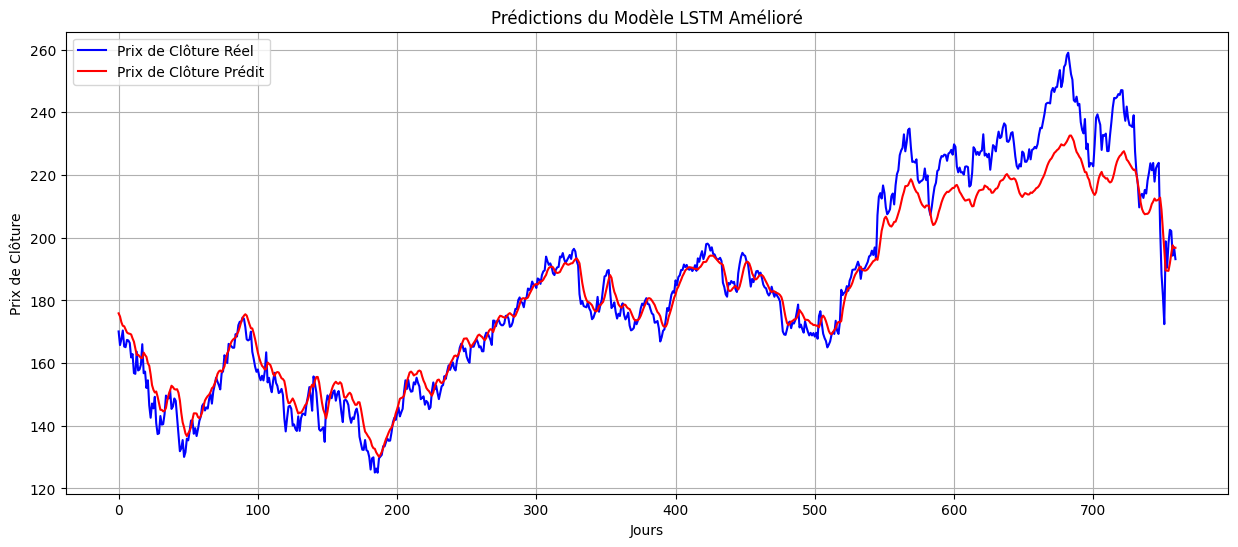

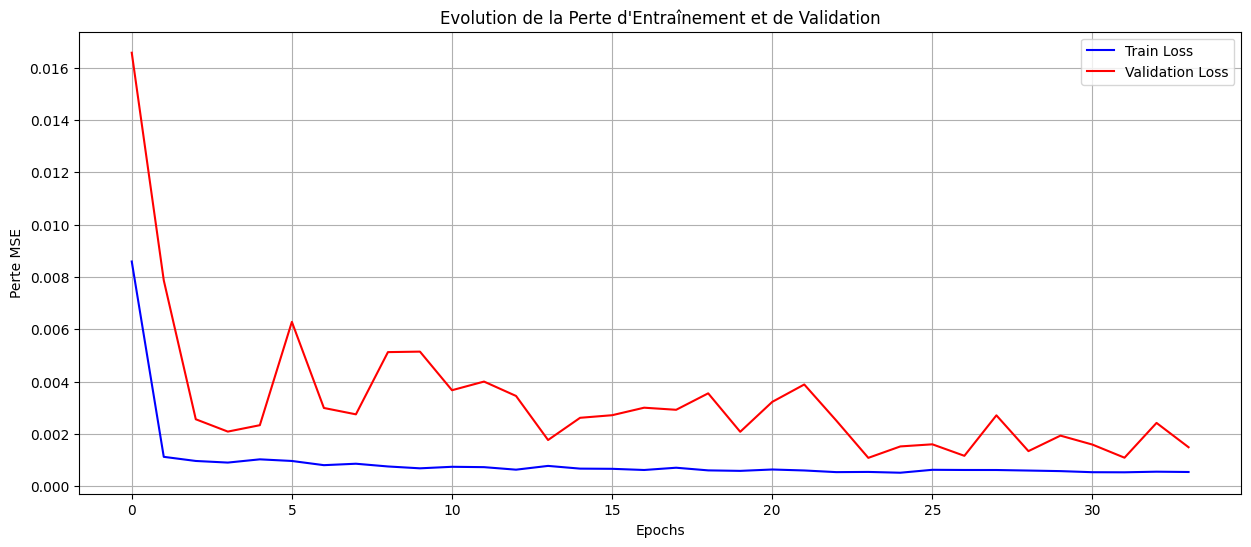

In [75]:
#  Prédictions VS Réel
plt.figure(figsize=(15, 6))
plt.plot(y_true_actual, label='Prix de Clôture Réel', color='blue')
plt.plot(y_pred_actual, label='Prix de Clôture Prédit', color='red')
plt.title('Prédictions du Modèle LSTM Amélioré')
plt.xlabel('Jours')
plt.ylabel('Prix de Clôture')
plt.legend()
plt.grid(True)
plt.show()

# Evolution de la perte d'entraînement et de validation
plt.figure(figsize=(15, 6))
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='red')
plt.title('Evolution de la Perte d\'Entraînement et de Validation')
plt.xlabel('Epochs')
plt.ylabel('Perte MSE')
plt.legend()
plt.grid(True)
plt.show()

Résultat du LSTM sans features engineering : <br>
MSE : 1466.4834<br>
RMSE : 38.2947<br>
MAE : 36.8715<br>
MAPE : 19.7894%

Résultat du LSTM avec features engineering : <br>
MSE : 68.1571<br>
RMSE : 8.2557<br>
MAE : 6.0093<br>
MAPE : 3.0862%

Résultats peu concluant pour le modèle sans feature engineering qui peine à capturer la dynamique temporelle et les relations de dépendance complexes dans les données financières.<br>
Les indicateurs techniques apportés par le feature engineering fournissent des informations dérivées essentielles pour aider le modèle à :<br>
    - Détecter des tendances (MA, EMA, MACD),<br>
    - Comprendre la volatilité et les retournements de tendance (RSI, Volatility),<br>
    - Saisir des patterns de momentum (Momentum).